In [1]:
#Load the model from the kaggle/dataset folder and save it as a zip file in the kaggle/working directory

import shutil
import os

# Set the source folder path (update with your actual dataset folder name)
source_model_folder = "/kaggle/input/phase1-model-train-with-first-move-in-state"  # Replace with your folder path

# Define the base name and destination for the zip file (without extension)
destination_base = "/kaggle/working/model"

# Zip the folder (this will create model.zip in /kaggle/working)
shutil.make_archive(base_name=destination_base, format="zip", root_dir=source_model_folder)

# Verify that the file now exists in /kaggle/working
print("Files in /kaggle/working:")
!ls /kaggle/working

Files in /kaggle/working:
model.zip  __notebook__.ipynb


/usr/local/lib/python3.10/dist-packages/tensorflow/lite/python/util.py:55: DeprecationWarning: jax.xla_computation is deprecated. Please use the AOT APIs; see https://jax.readthedocs.io/en/latest/aot.html. For example, replace xla_computation(f)(*xs) with jit(f).lower(*xs).compiler_ir('hlo'). See CHANGELOG.md for 0.4.30 for more examples.
  from jax import xla_computation as _xla_computation
/usr/local/lib/python3.10/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.num_envs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.num_envs` for environment variables or `env.get_attr('num_envs')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/save_util.py:437: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct mali

Episode: 100000, Total Reward: 1603.50, Total Bet: 110568.00, Reward/Bet Ratio: 1.45%
Episode: 200000, Total Reward: 2784.50, Total Bet: 220217.00, Reward/Bet Ratio: 1.26%
Episode: 300000, Total Reward: 3438.00, Total Bet: 330189.00, Reward/Bet Ratio: 1.04%
Episode: 400000, Total Reward: 4181.00, Total Bet: 439056.00, Reward/Bet Ratio: 0.95%
Episode: 500000, Total Reward: 4795.00, Total Bet: 547391.00, Reward/Bet Ratio: 0.88%
Episode: 600000, Total Reward: 5735.50, Total Bet: 655704.00, Reward/Bet Ratio: 0.87%
Episode: 700000, Total Reward: 6412.50, Total Bet: 765684.00, Reward/Bet Ratio: 0.84%
Episode: 800000, Total Reward: 6963.00, Total Bet: 876392.00, Reward/Bet Ratio: 0.79%
Episode: 900000, Total Reward: 7625.50, Total Bet: 985990.00, Reward/Bet Ratio: 0.77%
Episode: 1000000, Total Reward: 8458.00, Total Bet: 1096597.00, Reward/Bet Ratio: 0.77%
Episode: 1100000, Total Reward: 9234.50, Total Bet: 1205638.00, Reward/Bet Ratio: 0.77%
Episode: 1200000, Total Reward: 10154.00, Total Be

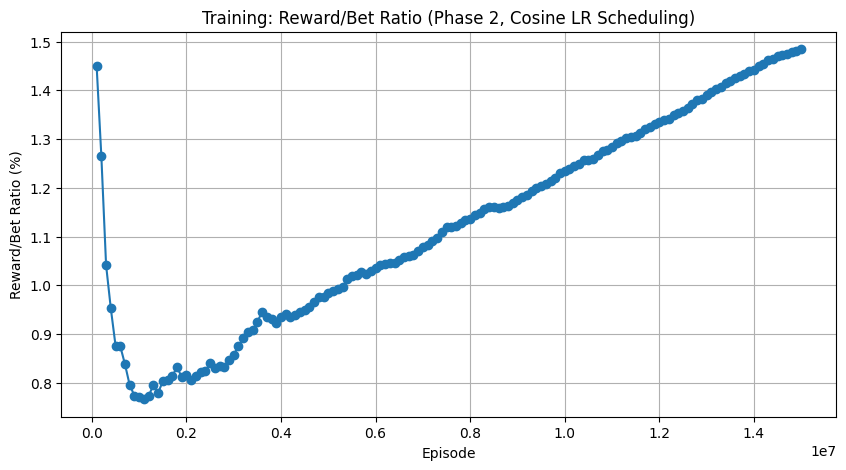

/usr/local/lib/python3.10/dist-packages/gymnasium/core.py:297: UserWarning: WARN: env.num_envs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.num_envs` for environment variables or `env.get_attr('num_envs')` that will search the reminding wrappers.
  logger.warn(
/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/save_util.py:437: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unl

Starting evaluation...
Episode 1000: Reward/Bet Ratio = -2.10%
Episode 2000: Reward/Bet Ratio = 1.35%
Episode 3000: Reward/Bet Ratio = 1.49%
Episode 4000: Reward/Bet Ratio = 1.91%
Episode 5000: Reward/Bet Ratio = 0.49%
Episode 6000: Reward/Bet Ratio = 1.14%
Episode 7000: Reward/Bet Ratio = 0.51%
Episode 8000: Reward/Bet Ratio = 1.01%
Episode 9000: Reward/Bet Ratio = 1.21%
Episode 10000: Reward/Bet Ratio = 1.71%
Episode 11000: Reward/Bet Ratio = 1.42%
Episode 12000: Reward/Bet Ratio = 0.71%
Episode 13000: Reward/Bet Ratio = 0.37%
Episode 14000: Reward/Bet Ratio = 0.20%
Episode 15000: Reward/Bet Ratio = 0.62%
Episode 16000: Reward/Bet Ratio = 0.54%
Episode 17000: Reward/Bet Ratio = 1.01%
Episode 18000: Reward/Bet Ratio = 1.14%
Episode 19000: Reward/Bet Ratio = 1.30%
Episode 20000: Reward/Bet Ratio = 1.39%
Episode 21000: Reward/Bet Ratio = 1.50%
Episode 22000: Reward/Bet Ratio = 1.57%
Episode 23000: Reward/Bet Ratio = 1.64%
Episode 24000: Reward/Bet Ratio = 1.83%
Episode 25000: Reward/Bet

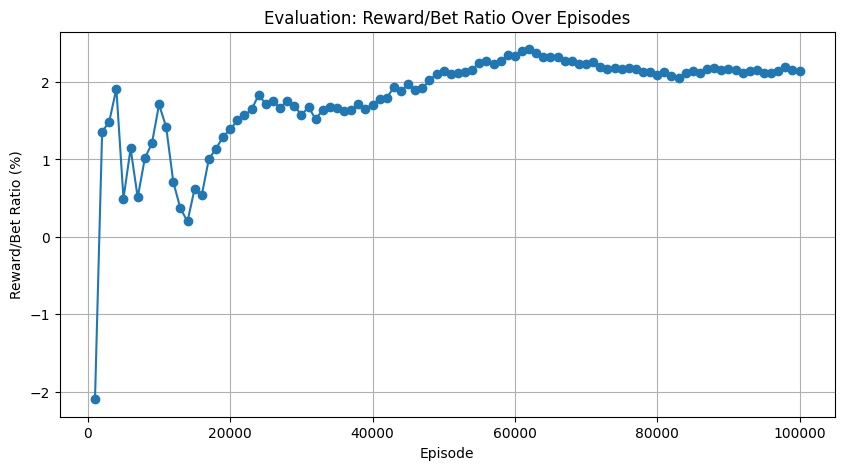

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
from gymnasium.wrappers import RecordEpisodeStatistics

# ----------------------------
# Environment Definition
# ----------------------------
class BlackjackEnvCountingFirstMove(gym.Env):
    """
    Custom Blackjack environment with card counting and a first-move flag.

    State (MultiDiscrete):
      [player_sum, usable_ace, dealer_card, is_first_move, cnt_A, cnt_2, ..., cnt_9, cnt_10group]

      - player_sum: Sum of player's hand (0 to 31)
      - usable_ace: 0 (no usable ace) or 1 (usable ace exists)
      - dealer_card: Dealer's face-up card (1 for Ace, 2–10 for number cards)
      - is_first_move: 1 if it's the first decision of the episode, 0 otherwise.
      - cnt_A: Count for Ace (0–4)
      - cnt_2 to cnt_9: Count for cards 2 through 9 (each 0–4)
      - cnt_10group: Count for 10, Jack, Queen, King (0–16)

    Actions (Discrete(4)):
      0: HIT      – Request another card.
      1: STK      – Stand.
      2: DBL      – Double Down (allowed only on the first move).
      3: SUR      – Surrender (allowed only on the first move).

    On moves after the first, only HIT (0) and STK (1) are allowed.
    
    Reward Structure:
      - Blackjack pays 3:2 (payout_blackjack=1.5) if only the player has blackjack.
      - Regular win pays 1:1.
      - Push returns 0.
      - Loss costs the bet.
      - Surrender returns -0.5 times the base bet.
      - Double Down outcomes are scaled (bet multiplied by 2).
    """
    def __init__(self, payout_blackjack=1.5, deck_threshold=15):
        super(BlackjackEnvCountingFirstMove, self).__init__()
        # Define the action space: 4 discrete actions
        self.action_space = spaces.Discrete(4)
        
        # Observation space:
        # [player_sum (32), usable_ace (2), dealer_card (11), is_first_move (2),
        #  cnt_A (5), cnt_2,...,cnt_9 (each 5), cnt_10group (17)]
        self.observation_space = spaces.MultiDiscrete([32, 2, 11, 2] + [5]*9 + [17])
        
        self.payout_blackjack = payout_blackjack
        self.base_bet = 1.0
        self.deck_threshold = deck_threshold
        
        self._init_deck()
        self.reset()
        
    def _init_deck(self):
        """Initialize a single deck and reset card counts."""
        self.deck = []
        self.deck += ['A'] * 4
        for card in range(2, 10):
            self.deck += [str(card)] * 4
        self.deck += ['10'] * 16
        random.shuffle(self.deck)
        
        self.card_counts = {'A': 0}
        for card in range(2, 10):
            self.card_counts[str(card)] = 0
        self.card_counts['10'] = 0
        
    def _draw_card(self):
        if len(self.deck) == 0:
            self._init_deck()
        card = self.deck.pop()
        if card == 'A':
            self.card_counts['A'] = min(self.card_counts['A'] + 1, 4)
        elif card == '10':
            self.card_counts['10'] = min(self.card_counts['10'] + 1, 16)
        else:
            self.card_counts[card] = min(self.card_counts[card] + 1, 4)
        return card
    
    def _hand_value(self, hand):
        total = 0
        ace_count = 0
        for card in hand:
            if card == 'A':
                total += 1
                ace_count += 1
            else:
                total += int(card)
        usable_ace = 0
        if ace_count > 0 and total + 10 <= 21:
            total += 10
            usable_ace = 1
        return total, usable_ace
    
    def _card_value(self, card):
        return 1 if card == 'A' else int(card)
    
    def _get_observation(self):
        player_sum, usable_ace = self._hand_value(self.player_hand)
        dealer_card_val = self._card_value(self.dealer_hand[0])
        first_move_flag = 1 if self.first_move else 0
        counts = [self.card_counts['A']]
        for card in range(2, 10):
            counts.append(self.card_counts[str(card)])
        counts.append(self.card_counts['10'])
        obs = np.array([player_sum, usable_ace, dealer_card_val, first_move_flag] + counts, dtype=np.int32)
        return obs
    
    def reset(self, seed=None, options=None):
        self.first_move = True
        self.done = False
        self.natural_blackjack = False
        if len(self.deck) < self.deck_threshold:
            self._init_deck()
        self.player_hand = [self._draw_card(), self._draw_card()]
        self.dealer_hand = [self._draw_card(), self._draw_card()]
        player_total, _ = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        if player_total == 21:
            self.reward = 0.0 if dealer_total == 21 else self.payout_blackjack * self.base_bet
            self.natural_blackjack = True
        else:
            self.reward = 0.0
        return self._get_observation(), {}
    
    def step(self, action):
        if self.natural_blackjack:
            self.natural_blackjack = False
            self.done = True
            info = {"bet": 1.0}
            return self._get_observation(), self.reward, True, False, info

        if self.done:
            return self._get_observation(), 0.0, True, False, {}
        
        if not self.first_move and action in [2, 3]:
            self.done = True
            return self._get_observation(), -1.0, True, False, {"illegal_action": True}
        
        if action == 0:  # HIT
            card = self._draw_card()
            self.player_hand.append(card)
            player_total, _ = self._hand_value(self.player_hand)
            if player_total > 21:
                self.done = True
                reward = -self.base_bet
            else:
                reward = 0.0
            self.first_move = False
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 1:  # STAND
            reward = self._dealer_play()
            self.done = True
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 2:  # DOUBLE DOWN
            self.first_move = False
            card = self._draw_card()
            self.player_hand.append(card)
            player_total, _ = self._hand_value(self.player_hand)
            if player_total > 21:
                reward = -2 * self.base_bet
                self.done = True
                return self._get_observation(), reward, self.done, False, {}
            reward = self._dealer_play(double_down=True)
            self.done = True
            return self._get_observation(), reward, self.done, False, {}
        
        elif action == 3:  # SURRENDER
            self.first_move = False
            self.done = True
            reward = -0.5 * self.base_bet
            return self._get_observation(), reward, self.done, False, {}
        else:
            self.done = True
            return self._get_observation(), -1.0, True, False, {"illegal_action": True}
    
    def _dealer_play(self, double_down=False):
        player_total, _ = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        while dealer_total < 17:
            card = self._draw_card()
            self.dealer_hand.append(card)
            dealer_total, _ = self._hand_value(self.dealer_hand)
        bet = self.base_bet * (2 if double_down else 1)
        if dealer_total > 21:
            return bet
        elif dealer_total > player_total:
            return -bet
        elif dealer_total < player_total:
            return bet
        else:
            return 0.0
       
    def render(self, mode='human'):
        player_total, usable = self._hand_value(self.player_hand)
        dealer_total, _ = self._hand_value(self.dealer_hand)
        print(f"Player hand: {self.player_hand} (Total: {player_total}, Usable Ace: {usable})")
        print(f"Dealer hand: {self.dealer_hand} (Total: {dealer_total})")
        print("Card counts:", self.card_counts)
        print("First move:", self.first_move)

# ----------------------------
# Phase 2 Cosine LR Schedule: from 1e-6 to 1e-7
# ----------------------------
def cosine_lr_schedule_phase2(progress_remaining):
    lr_initial = 1e-6
    lr_min = 1e-7
    cosine_decay = 0.5 * (1 + math.cos(math.pi * (1 - progress_remaining)))
    return lr_min + (lr_initial - lr_min) * cosine_decay

# ----------------------------
# Custom Wrapper to Attach Bet Info
# ----------------------------
class BetInfoWrapper(gym.Wrapper):
    def __init__(self, env):
        super(BetInfoWrapper, self).__init__(env)
    
    def step(self, action):
        self.last_action = action
        obs, reward, terminated, truncated, info = self.env.step(action)
        if terminated or truncated:
            info["bet"] = 2.0 if self.last_action == 2 else 1.0
        return obs, reward, terminated, truncated, info

# ----------------------------
# Training Metrics Callback
# ----------------------------
class TrainingMetricsCallback(BaseCallback):
    def __init__(self, print_freq=100_000, verbose=0):
        super(TrainingMetricsCallback, self).__init__(verbose)
        self.print_freq = print_freq
        self.total_reward = 0.0
        self.total_bet = 0.0
        self.episode_count = 0
        self.episode_history = []
        self.ratio_history = []
    
    def _on_step(self) -> bool:
        infos = self.locals.get("infos", None)
        if infos is not None:
            if isinstance(infos, list):
                for info in infos:
                    if "episode" in info:
                        self.episode_count += 1
                        self.total_reward += info["episode"]["r"]
                        self.total_bet += info.get("bet", 1.0)
                        if self.episode_count % self.print_freq == 0:
                            ratio = (self.total_reward / self.total_bet * 100.0) if self.total_bet > 0 else 0.0
                            print(f"Episode: {self.episode_count}, Total Reward: {self.total_reward:.2f}, "
                                  f"Total Bet: {self.total_bet:.2f}, Reward/Bet Ratio: {ratio:.2f}%")
                            self.episode_history.append(self.episode_count)
                            self.ratio_history.append(ratio)
            else:
                if "episode" in infos:
                    self.episode_count += 1
                    self.total_reward += infos["episode"]["r"]
                    self.total_bet += infos.get("bet", 1.0)
                    if self.episode_count % self.print_freq == 0:
                        ratio = (self.total_reward / self.total_bet * 100.0) if self.total_bet > 0 else 0.0
                        print(f"Episode: {self.episode_count}, Total Reward: {self.total_reward:.2f}, "
                              f"Total Bet: {self.total_bet:.2f}, Reward/Bet Ratio: {ratio:.2f}%")
                        self.episode_history.append(self.episode_count)
                        self.ratio_history.append(ratio)
        return True

# ----------------------------
# Create and Check the Training Environment
# ----------------------------
env = BlackjackEnvCountingFirstMove()
env = BetInfoWrapper(env)
env = RecordEpisodeStatistics(env)
check_env(env, warn=True)

# ----------------------------
# Load Phase1 Model and Update LR Schedule for Phase 2
# ----------------------------
model = PPO.load("model", env=env)
# Update the learning rate schedule for further training
model.learning_rate = cosine_lr_schedule_phase2

# Create training metrics callback for phase 2 training
metrics_callback = TrainingMetricsCallback(print_freq=100_000, verbose=0)

# ----------------------------
# Further Train the Model (Additional 20,000,000 timesteps)
# ----------------------------
model.learn(total_timesteps=20_000_000, callback=metrics_callback)

# Save the further trained model
model.save("ppo_blackjack_model_phase2")
print("Further training complete and saved as 'ppo_blackjack_model_phase2'.")

# ----------------------------
# Plot the Training Reward/Bet Ratio
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(metrics_callback.episode_history, metrics_callback.ratio_history, marker='o', linestyle='-')
plt.title("Training: Reward/Bet Ratio (Phase 2, Cosine LR Scheduling)")
plt.xlabel("Episode")
plt.ylabel("Reward/Bet Ratio (%)")
plt.grid(True)
plt.show()

# ----------------------------
# Evaluation of the Further Trained Model
# ----------------------------
eval_env = BlackjackEnvCountingFirstMove()
eval_env = BetInfoWrapper(eval_env)
eval_env = RecordEpisodeStatistics(eval_env)

# Load the further trained model into the evaluation environment
model = PPO.load("ppo_blackjack_model_phase2", env=eval_env)

num_episodes = 100_000
reward_history = []
bet_history = []
ratio_history_eval = []
episode_x = []

wins = 0
draws = 0
losses = 0

print("Starting evaluation...")
for episode in range(1, num_episodes + 1):
    obs, _ = eval_env.reset()
    done = False
    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = eval_env.step(action)
    episode_reward = reward
    episode_bet = info.get("bet", 1.0)
    
    reward_history.append(episode_reward)
    bet_history.append(episode_bet)
    
    if episode_reward > 0:
        wins += 1
    elif episode_reward == 0:
        draws += 1
    else:
        losses += 1
    
    if episode % 1000 == 0:
        total_reward = np.sum(reward_history)
        total_bet = np.sum(bet_history)
        ratio = (total_reward / total_bet * 100) if total_bet > 0 else 0.0
        ratio_history_eval.append(ratio)
        episode_x.append(episode)
        print(f"Episode {episode}: Reward/Bet Ratio = {ratio:.2f}%")

win_percent = wins / num_episodes * 100
draw_percent = draws / num_episodes * 100
loss_percent = losses / num_episodes * 100

print("\nFinal Evaluation Results:")
print(f"Win %: {win_percent:.2f}%")
print(f"Draw %: {draw_percent:.2f}%")
print(f"Loss %: {loss_percent:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(episode_x, ratio_history_eval, marker='o', linestyle='-')
plt.title("Evaluation: Reward/Bet Ratio Over Episodes")
plt.xlabel("Episode")
plt.ylabel("Reward/Bet Ratio (%)")
plt.grid(True)
plt.show()